# 🧑‍💼 **Business Context:** Los Angeles Crime Analysis

###**Client Company:**  
Assumed law enforcement or local government, optimizing public safety and resources in Los Angeles.

###**Data:**  
Client has a database of reported crimes from various locations, with information including:

* **Date and Time of Crime**
* **Location of Crime**
* **Type of Crime**
* **Suspect and Victim Information**
* **Other Information**

###**Client Needs:**

1. **Explore Crime Trends:** Uncover patterns, time and area shifts using exploratory data analysis and visualization.
2. **Determine Crime Hotspots:** Map crime hot spots to guide police patrol and allocate resources.
3. **Extract Actionable Insights:** Provide actionable recommendations to law enforcement to improve public safety.

###**Why they would need a data scientist:**

* **Enable insight into crime trends:** To uncover useful correlations and trends beyond descriptive statistics.
* **Enable smarter use of resources:** To direct resources more wisely towards areas and classes of crimes.
* **Enable proactive prevention of crime:** To use past trends of crime to implement preemptive measures.
* **Support data-driven decisions:** To dictate policies and action designed to secure public safety.

# 📑 **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

# 📥 **Data Loading**
Link to the dataset: https://www.kaggle.com/datasets/ishajangir/crime-data/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_crime = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crime_Data_from_2020_to_Present.csv')
print(df_crime.shape)
df_crime.head(1)

(1003448, 28)


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506


# 🕵️ **Data Exploration**


View and examine data types


In [ ]:
df_crime.dtypes

,0
DR_NO,int64
Date Rptd,object
DATE OCC,object
TIME OCC,int64
AREA,int64
AREA NAME,object
Rpt Dist No,int64
Part 1-2,int64
Crm Cd,int64
Crm Cd Desc,object


Used ```describe()``` only on `Vict Age` as the other numeric values are either 'ID' based or irrelevant.

In [ ]:
df_crime['Vict Age'].describe()

,Vict Age
count,1.003448e+06
mean,2.891332e+01
std,2.199538e+01
min,-4.000000e+00
25%,0.000000e+00
50%,3.000000e+01
75%,4.400000e+01
max,1.200000e+02


As we can see, some of the `Vict Age` values are negative and the maximum age is too high. We will rectify this in the upcoming code cells.
___

Checking duplicates

In [ ]:
print(df_crime.duplicated().sum())

0


Check for missing values and calculate the percentage of missing values.


In [ ]:
missing_values = df_crime.isnull().sum()
missing_percentage = round((missing_values / len(df_crime)) * 100, 2)
missing_percentage

,0
DR_NO,0.00
Date Rptd,0.00
DATE OCC,0.00
TIME OCC,0.00
AREA,0.00
AREA NAME,0.00
Rpt Dist No,0.00
Part 1-2,0.00
Crm Cd,0.00
Crm Cd Desc,0.00


Here we see that many columns have `null` values. We will rectify this in the upcoming code cells.

# 🫧 **Data Cleaning**

Drop `Cross Street` and `Mocodes` as they are not relevant in the analysis


In [ ]:
df_crime.drop(['Cross Street' , 'Mocodes'] , axis = 1 ,inplace = True)

**Description of dropped columns**:


**Mocodes:** Modus operandi codes, describing the method used in the crime.

**Cross Street:** Nearby cross street for the crime location.

___

Fill null values in Crime Codes with `'No Other Crime'` as no other crimes present.

In [ ]:
df_crime['Crm Cd 1'] = df_crime['Crm Cd 1'].fillna('No Other Crime')
df_crime['Crm Cd 2'] = df_crime['Crm Cd 2'].fillna('No Other Crime')
df_crime['Crm Cd 3'] = df_crime['Crm Cd 3'].fillna('No Other Crime')
df_crime['Crm Cd 4'] = df_crime['Crm Cd 4'].fillna('No Other Crime')

Fill null values in `Weapon Used Cd` and `Weapon Desc` with relevant values


In [ ]:
df_crime['Weapon Used Cd'] = df_crime['Weapon Used Cd'].fillna(0)
df_crime['Weapon Desc'] = df_crime['Weapon Desc'].fillna('No Weapon')

Removed values in `Vict Age` where value  `>= 0` and `< 120` based on data exploration findings.

In [ ]:
df_crime = df_crime[(df_crime['Vict Age'] >= 0) & (df_crime['Vict Age'] < 120)]

___

**Cleaning incorrect `'Vict Age = 0'` rows.**

There are a high number of `Vict Age = 0` which look like they are associated with wrong `Crm Cd Desc`.

The crimes for `Vict Age = 0` are shown below:

In [ ]:
df_crime[df_crime['Vict Age'] == 0]['Crm Cd Desc'].value_counts().head(10)

,count
Crm Cd Desc,
VEHICLE - STOLEN,114839
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),25026
SHOPLIFTING - PETTY THEFT ($950 & UNDER),21404
BURGLARY,18099
"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",14686
TRESPASSING,9646
"THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD",7417
THEFT PLAIN - PETTY ($950 & UNDER),6760
ROBBERY,6495


Remove various wrong age rows with `Vict Age = 0` as other crimes were based on adults.


In [ ]:
# List of crime descriptions to keep
keep_crimes = ['CHILD NEGLECT (SEE 300 W.I.C.)',
               'CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT',
               'CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT',
               'KIDNAPPING',
               'KIDNAPPING - GRAND ATTEMPT',
               'CHILD STEALING',
               'CHILD ABANDONMENT']

# Filter the DataFrame
df_crime = df_crime[
    (df_crime['Vict Age'] != 0) |                                              # Keep rows where age is not 0
    (df_crime['Vict Age'] == 0) & (df_crime['Crm Cd Desc'].isin(keep_crimes))  # Keep rows where age is 0 and crime description is in the list
]

Clean `Vict Sex` where we replace incorrect values with `Unknown`

In [ ]:
#Display unique values in 'Victim Sex'
print('Before: ', df_crime['Vict Sex'].unique())

Before:  ['M' 'X' 'F' 'H' nan]


In [ ]:
#Replace irrelevant data with 'NaN' and then replace with 'Unknown'
df_crime['Vict Sex'] = df_crime['Vict Sex'].replace({'X' : np.nan, 'H' : np.nan, '-' : np.nan})
df_crime['Vict Sex'] = df_crime['Vict Sex'].fillna('Unknown')

Drop rows with `NA` values as there are low number of null values in irrelevant columns.


In [ ]:
df_crime.dropna(inplace=True)

Check for missing values after cleaning


In [ ]:
missing_values = df_crime.isnull().sum()
missing_percentage = (missing_values / len(df_crime)) * 100
missing_percentage

,0
DR_NO,0.0
Date Rptd,0.0
DATE OCC,0.0
TIME OCC,0.0
AREA,0.0
AREA NAME,0.0
Rpt Dist No,0.0
Part 1-2,0.0
Crm Cd,0.0
Crm Cd Desc,0.0


Check for duplicates after cleaning

In [ ]:
print(df_crime.duplicated().sum())

0


Reset index due to dropping rows

In [ ]:
df_crime = df_crime.reset_index(drop = True)

# 📊 **Data Analysis**


## **Q.1)** Across all the years, what is the total number of crimes reported and when does it peak over the months?

Total number of reported crimes: 734760


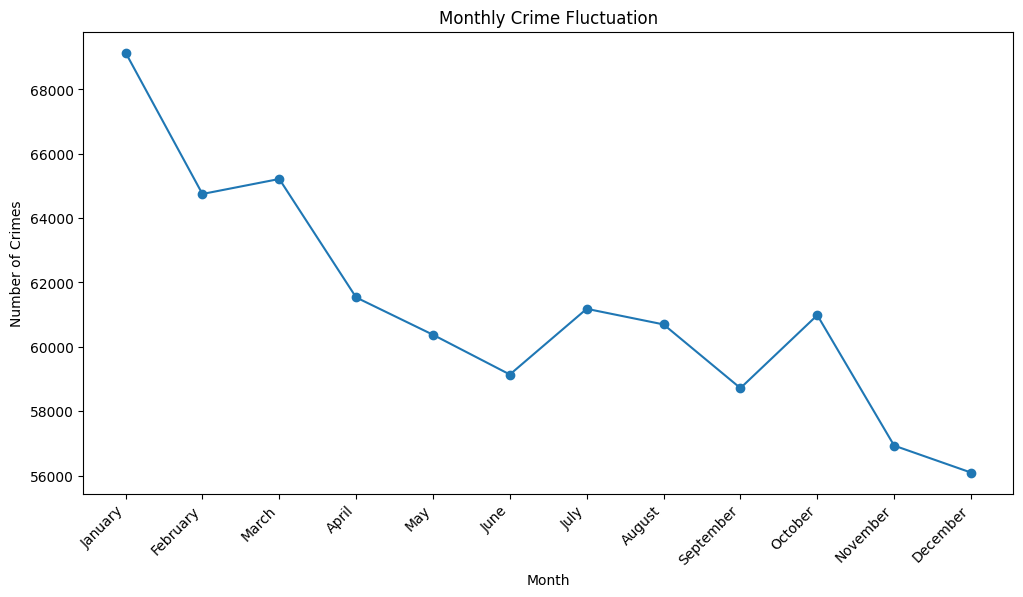

In [ ]:
# Total number of reported crimes
total_crimes = len(df_crime)
print(f"Total number of reported crimes: {total_crimes}")

# Crime rate fluctuation over the months
df_crime['DATE OCC'] = pd.to_datetime(df_crime['DATE OCC'])                   # Convert the 'DATE OCC' column to datetime objects
monthly_crime = df_crime.groupby(df_crime['DATE OCC'].dt.month_name()).size() # Monthly crime fluctuation with month names
month_order = list(calendar.month_name[1:])                                   # Get all month names in order
monthly_crime = monthly_crime.reindex(month_order)                            # Reindex the monthly_crime Series using the month order

#Create the plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_crime.index, monthly_crime.values, marker='o')
plt.title('Monthly Crime Fluctuation')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.show()

### **Result:**

Total crime reported is `73.5k`. January `(69146)` reports the highest crime, then comes March `(65218)` followed by February `(64751)`. Lowest crime rate is in December `(56096)`.

### **Answer to Business Question:**

The reported number of crimes is 734792. Crime rates have been on the decline throughout the year based on the trend, which suggests seasonal or external influences on criminal behaviour. The authorities can respond to the heightened incidence during that period.


## **Q.2)** Which of the crimes are more common?

Creating custom bar chart function for reusability.

In [ ]:
def plot_bar_chart(data, title, xlabel, ylabel, rotation=90, fontsize=6):

  plt.figure(figsize=(10, 5))
  bars = plt.bar(data.index, data.values)
  plt.xticks(rotation=rotation, fontsize=fontsize)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)

  # Add labels to the bars
  for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), va='bottom', ha='center')
  plt.show()

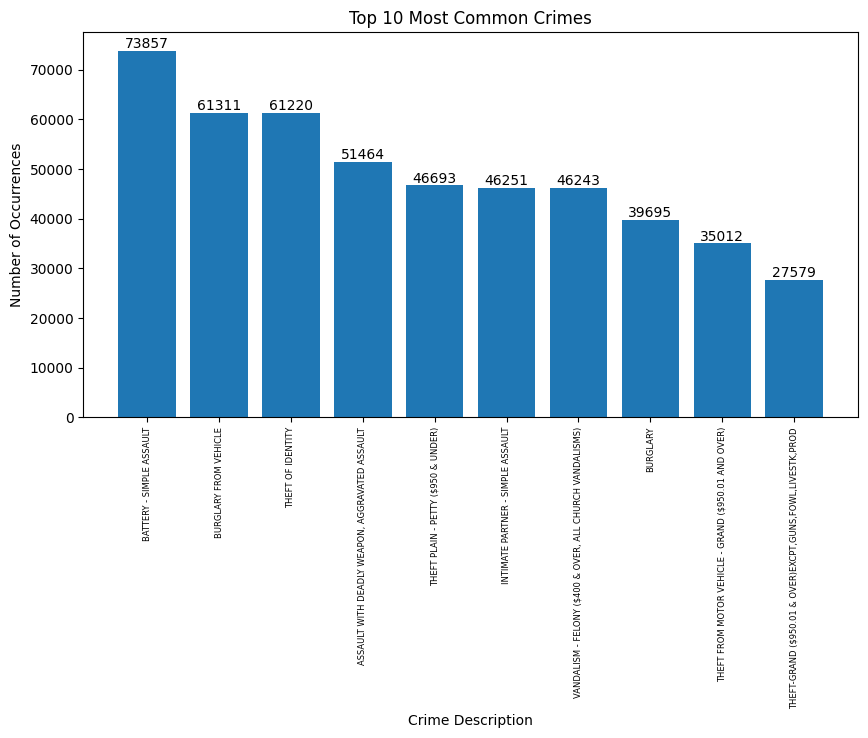

In [ ]:
# Most common types of crimes
crime_counts = df_crime['Crm Cd Desc'].value_counts()
top_10_crimes = crime_counts.head(10) # Get the top 10 most frequent crimes

# Using custom bar plot function
plot_bar_chart(top_10_crimes,'Top 10 Most Common Crimes',
               'Crime Description','Number of Occurrences')

### **Result:**

 Battery - Simple Assault (73,000), Burglary from Vehicle (61312) and Theft of Identity (61220) are the top 3 common crimes.

### **Answer to Business Question:**

 The most common crimes are Battery - Simple Assault, Burglary from Vehicle, and Theft of Identity. These crimes occur more often when compared to others. Therefore, they can/may be identified as potential entry points for law enforcement to lower their occurrence.

## **Q.3)** What is the correlation between the time of occurrence and the area of crimes?


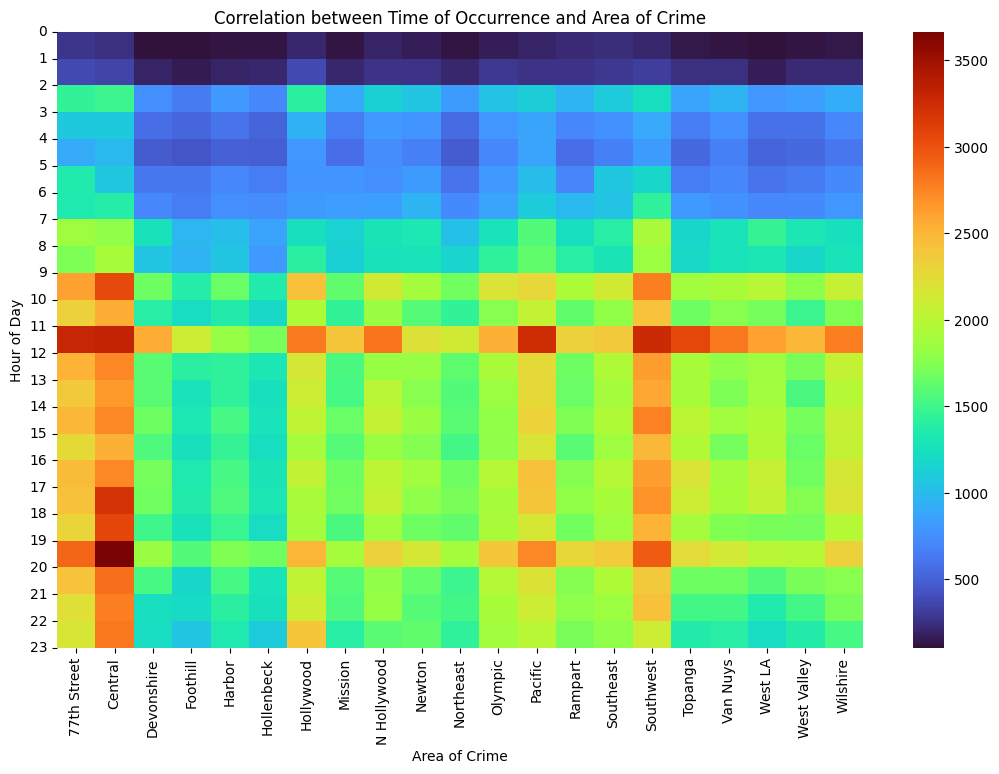

In [ ]:
# Correlation between time of occurrence and area type
df_crime['TIME OCC'] = pd.to_datetime(df_crime['TIME OCC'], format='%H%M', errors='coerce') # Convert 'TIME OCC' to datetime objects
df_crime['Hour'] = df_crime['TIME OCC'].dt.hour                                             # Extract all hours
crime_by_time_type = df_crime.groupby(['Hour', 'AREA NAME'])['Crm Cd'].count().unstack()    # Group by 'Hour' and 'AREA NAME'

# Create the heatmap
plt.figure(figsize=(13, 8))
sns.heatmap(crime_by_time_type.fillna(0), cmap='turbo', annot=False)
plt.title('Correlation between Time of Occurrence and Area of Crime')
plt.xlabel('Area of Crime')
plt.ylabel('Hour of Day')
plt.yticks(range(24), range(24))  # Set y-axis ticks to represent hours 0-23
plt.show()


### **Result:**

Red/Orange represent more crime incidents, and Blue/Purple represent lesser incidents.

### **Answer to Business Question:**

- Frequency of crimes are the least, late at night till early morning (12AM - 5AM).
- Frequency of crime is high from morning (6AM) and peaks during the midday (11AM - 1PM) and in the evening (6PM - 9PM).
- During peak hours, the most crimes occur at areas such as 77th Street, Central and Southwest.
- The correlation shows that crime is likely to rise at times when the public is active, in accordance with commuting, business, and social time.
- The police have to focus on these areas and increase patrolling in the peak hours.

## **Q.4)** Which crimes are more common in residential areas than in commercial ones?


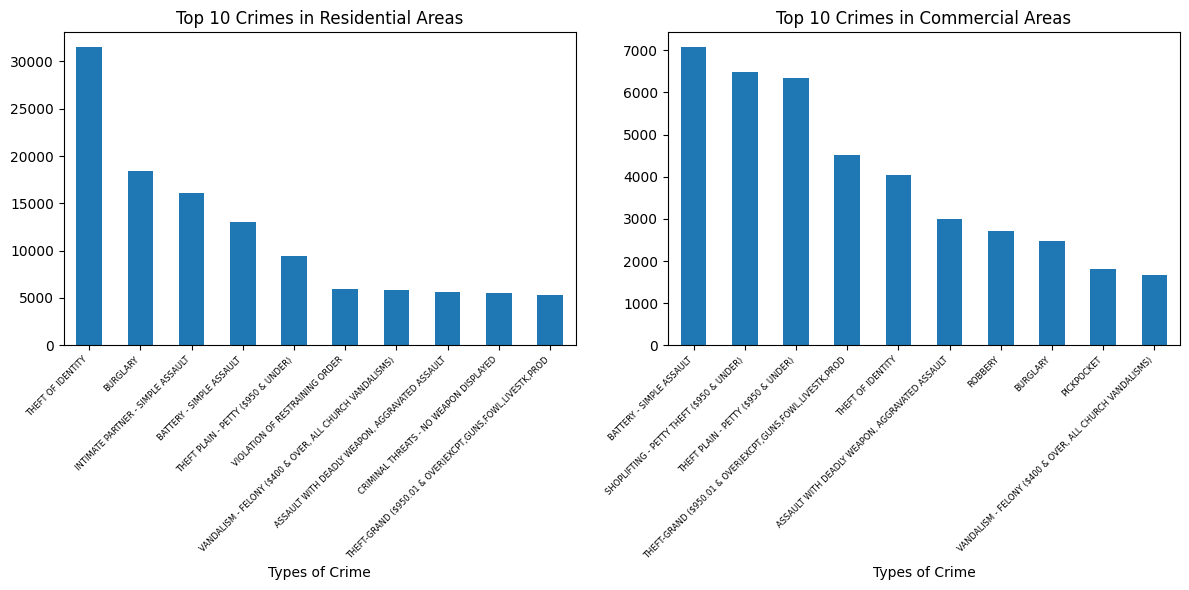

In [ ]:
# Most common crime types in residential areas vs. commercial zones

# List of Residence related Premises
residence_list = 'MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)|SINGLE FAMILY DWELLING|CONDOMINIUM/TOWNHOUSE|OTHER RESIDENCE|FRAT HOUSE/SORORITY/DORMITORY|PRIVATE SCHOOL/PRESCHOOL|FOSTER HOME BOYS OR GIRLS|OTHER PLACE OF WORSHIP'
# List of Commercial related Premises
commericial_list = 'CLOTHING STORE|GAS STATION|RESTAURANT/FAST FOOD|GOVERNMENT FACILITY|MARKET|DRUG STORE|NAIL SALON|DISCOUNT STORE|HOTEL|MOTEL|LAUNDROMAT|CONSTRUCTION SITE|MINI-MART|CONVENTION CENTER|RECYCLING CENTER|JUNIOR HIGH SCHOOL|NIGHT CLUB|COFFEE SHOP|BEAUTY/BARBER SHOP|HEALTH SPA/GYM|DEPARTMENT STORE|FURNITURE STORE|DRIVE THRU|ELECTRONICS STORE|LIQUOR STORE|CELL PHONE STORE|JEWELRY STORE|AUTO SALES LOT|BAR/COCKTAIL/NIGHTCLUB|MEMBERSHIP STORE|BANK|THEATRE/MOVIE|SPORTS VENUE|VETERINARIAN/ANIMAL HOSPITAL|RECORD-CD MUSIC|TATTOO PARLOR|CEMETARY|AMUSEMENT PARK|MEDICAL MARIJUANA FACILITIES|TRUCK, COMMERCIAL|CATERING/ICE CREAM TRUCK|FINANCE COMPANY|CULTURAL SIGNIFICANCE|COMPUTER SERVICES/REPAIRS/SALES|ESCALATOR|BOWLING ALLEY|GARMENT MANUFACTURER|SURPLUS SURVIVAL STORE|OIL REFINERY|VIDEO RENTAL STORE|HOCKEY RINK/ICE HOCKEY|SEWAGE FACILITY/PIPE'

# Filter 2 new subset DFs containing Residential and Commercial premise crime data.
residential_crimes = df_crime[df_crime['Premis Desc'].str.contains(residence_list, case=False, na=False)]['Crm Cd Desc'].value_counts()
commercial_crimes = df_crime[df_crime['Premis Desc'].str.contains(commericial_list, case=False, na=False)]['Crm Cd Desc'].value_counts()

# Create the subplots
plt.figure(figsize=(12, 6))

# Residential bar plot
plt.subplot(1, 2, 1)
residential_crimes.head(10).plot(kind='bar')
plt.title('Top 10 Crimes in Residential Areas')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.xlabel('Types of Crime')  # Change x-axis label here
# Commercial bar plot
plt.subplot(1, 2, 2)
commercial_crimes.head(10).plot(kind='bar')
plt.title('Top 10 Crimes in Commercial Areas')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.xlabel('Types of Crime')  # Change x-axis label here

plt.tight_layout()
plt.show()

### **Result:**

  Compared to commercial areas, the crime rate is higher in residential areas.  Burglary, Intimate Partner (Assault), and Identity Theft are more common in residential areas.  Shoplifting, Theft Plain, and Battery (Assault) are the top three crimes in commercial areas.

### **Answer to Business Question:**

 Since criminal activity in residential areas is high, the police ought to concentrate their attention there.  The government might maintain police aid stations near residential areas and raise awareness of police helplines in these regions.
 Alarm and surveillance systems (cameras) should be installed at commercial areas and residential areas.



## **Q.5)** Which age groups are most impacted by criminal activity?

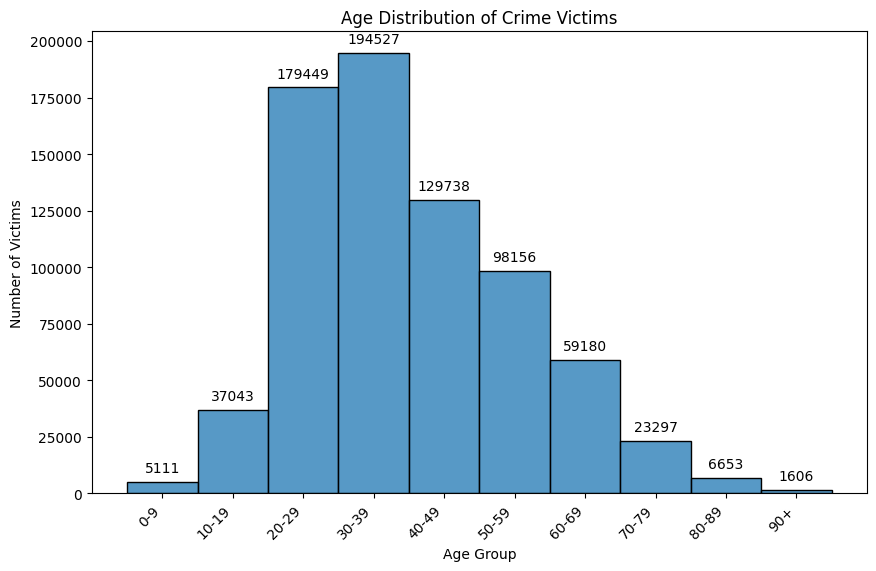

In [ ]:
# Age distribution of crime victims

# Create the graph
plt.figure(figsize=(10, 6))
# Categorize victims into age groups (10-year ranges)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']
df_crime['Age Group'] = pd.cut(df_crime['Vict Age'], bins = bins, labels = labels, right = False)
# Create the histogram with age groups
ax = sns.histplot(df_crime['Age Group'], kde=False)
plt.title('Age Distribution of Crime Victims')
plt.xlabel('Age Group')
plt.ylabel('Number of Victims')
plt.xticks(rotation=45, ha='right')
# Add labels to the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points')
plt.show()

### **Result:**

 The age groups most affected with highest number of crimes are 30-39 (194534), 20-29 (179461), and 40-49 (129741). The least affected are under the 90+ category (1606) and 0-9 category (5112). The crimes fall steadily for older age groups.

### **Answer to Business Question:**

 Young and middle-aged adults (20 to 49) are the most victimized by crime. Both groups must be prioritized by the government through community safety, self-defense, and awareness. The low figure of victims among the older age brackets could either be underreported or have lower exposure to crime.


## **Q.6)** Which are the most common crimes committed by juveniles? How can we prevent it?

`'Status'` column can be used to identify juvenile crimes.

In [ ]:
df_crime['Status'].unique()

array(['IC', 'AA', 'AO', 'JA', 'JO', 'CC'], dtype=object)

`'Status Desc'` provides an explanation of each value in `'Status'` below:
- IC: Investigation Continuing
- AA: Adult Arrest
- AO: Adult Other
- JA: Juvenile Arrest
- JO: Juvenile Other
- CC: Case Closed

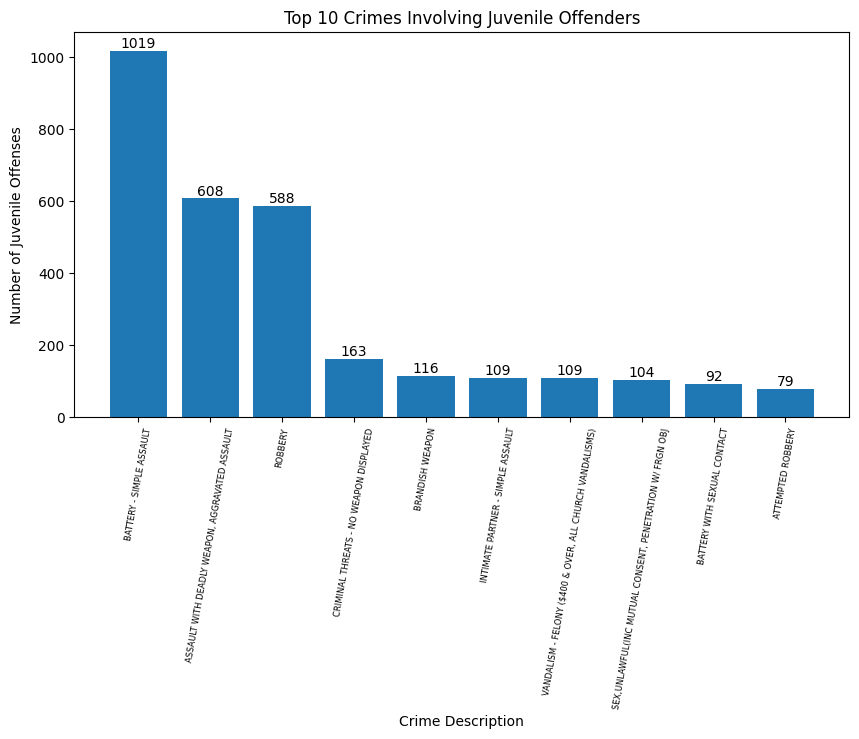

In [ ]:
# Top crimes involving juvenile offenders

juvenile_df = df_crime[df_crime['Status'].str.startswith('J', na=False)]  # Filter the DF to include only juvenile offenders
juvenile_crime_counts = juvenile_df['Crm Cd Desc'].value_counts()         # Group by crime description and count the number of juvenile offenses
top_10_juvenile_crimes = juvenile_crime_counts.head(10)                   # Get the top 10 most frequent crimes involving juveniles

# Re-use bar plot function from Q.2
plot_bar_chart(top_10_juvenile_crimes, 'Top 10 Crimes Involving Juvenile Offenders',
               'Crime Description', 'Number of Juvenile Offenses',
               rotation=80)


### **Result:**

 Robbery, Battery (Assault), and Aggravated Assault are the leading offenses with juveniles. The crimes that populate the list are marked by physical violence offenses which suggest that fights and possibly socioeconomic factors are the primary drivers of the offenses.

### **Answer to Business Question:**
 Early intervention programs should offer social support, anger management, and counseling in schools to lower crime rates. Parental guidance and educational workshops on conflict resolution can defuse criminal activity.  Positive alternatives to crime are provided by involvement in sports, mentorship programs, and after-school activities. Schools should teach students about the legal repercussions of criminal behaviour.


## **Q.7)** Which top 10 crimes have been solved and which have not?


We will use `'Arrest'` from the below list of values to identify solved and unsolved cases.

In [ ]:
df_crime['Status Desc'].unique()

array(['Invest Cont', 'Adult Arrest', 'Adult Other', 'Juv Arrest',
       'Juv Other', 'UNK'], dtype=object)

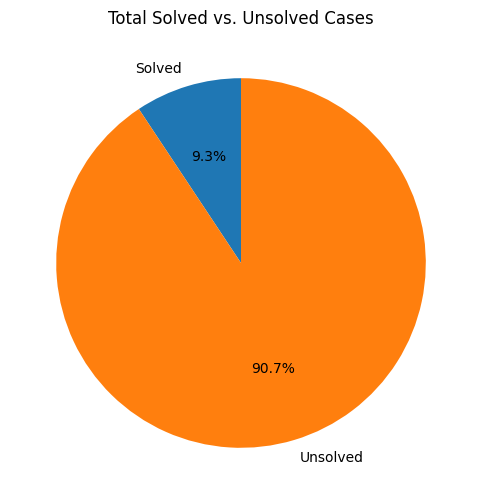

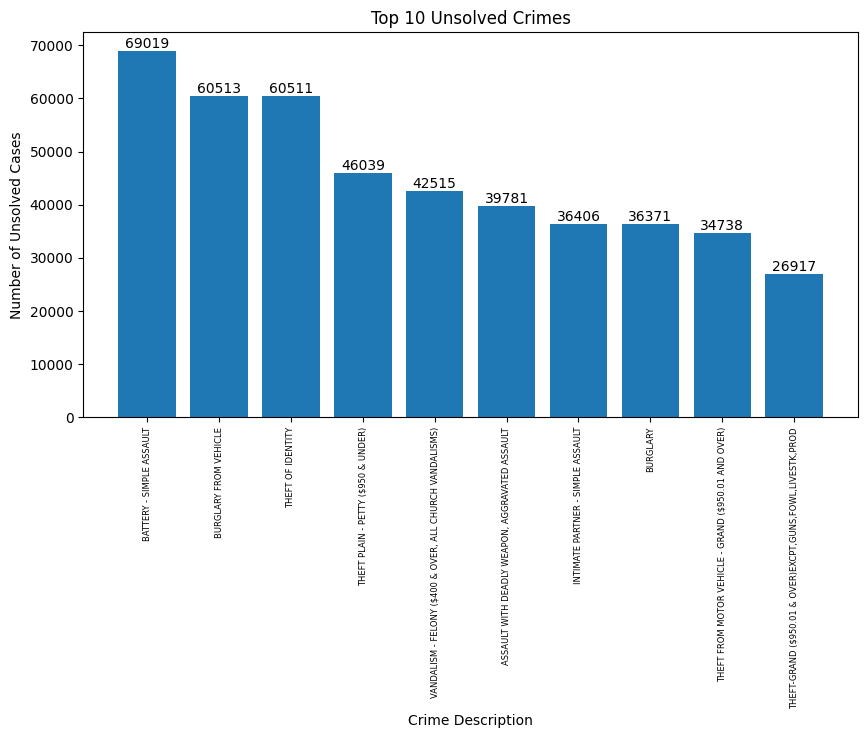

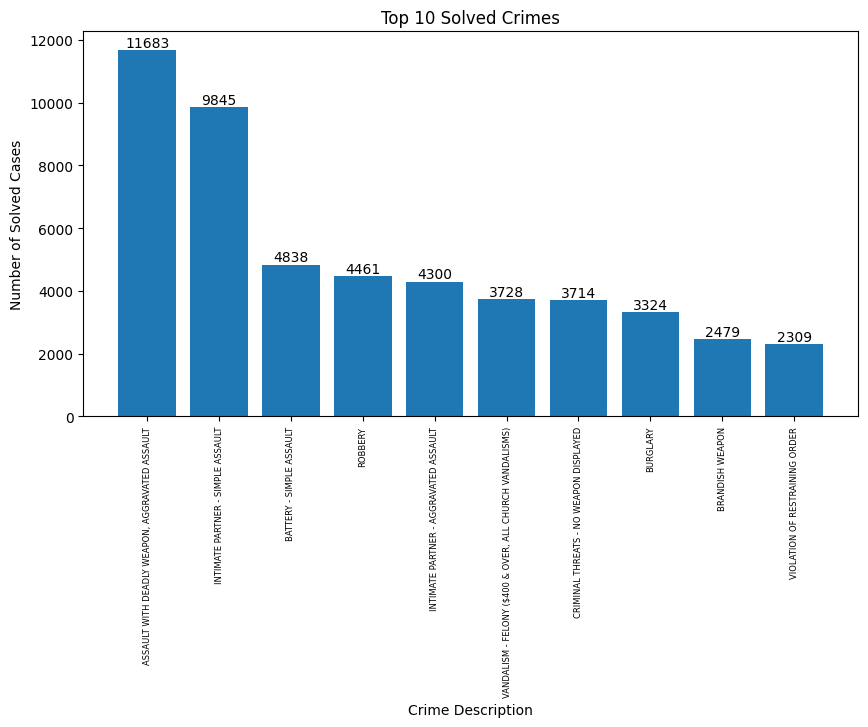

In [ ]:
# Top 10 solved and unsolved crimes

df_crime['Solved'] = df_crime['Status Desc'].str.contains('Arrest', na=False)               # Create new column 'Solved' from 'Status Desc' using 'Arrest'
crime_status = df_crime.groupby('Crm Cd Desc')['Solved'].agg(['sum', 'size'])               # Group by 'Crm Cd Desc' and count solved cases
crime_status.rename(columns={'sum': 'Solved Cases', 'size': 'Total Cases'}, inplace=True)
crime_status['Unsolved Cases'] = crime_status['Total Cases'] - crime_status['Solved Cases'] # Calculate unsolved cases using solved cases
top_10_unsolved = crime_status.sort_values('Unsolved Cases', ascending=False).head(10)      # Sort by unsolved cases in descending order to get the top 10 unsolved crimes
top_10_solved = crime_status.sort_values('Solved Cases', ascending=False).head(10)          # Sort by solved cases in descending order to get the top 10 solved crimes

# Solved vs. Unsolved Cases
total_solved = crime_status['Solved Cases'].sum()
total_unsolved = crime_status['Unsolved Cases'].sum()
# Create the pie chart
plt.figure(figsize=(8, 6))
plt.pie([total_solved, total_unsolved],
        labels=['Solved', 'Unsolved'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Total Solved vs. Unsolved Cases')
plt.show()

#Create the graphs
# Visualize the top 10 unsolved crimes
# Re-use bar plot function from Q.2
plot_bar_chart(top_10_unsolved['Unsolved Cases'], 'Top 10 Unsolved Crimes',
               'Crime Description', 'Number of Unsolved Cases')

# Visualize the top 10 solved crimes
# Re-use bar plot function from Q.2
plot_bar_chart(top_10_solved['Solved Cases'], 'Top 10 Solved Crimes',
               'Crime Description', 'Number of Solved Cases')

### **Result:**

 `9.3%` of cases are solved, compared to `90.7%` of cases that remain unsolved. The top 3 unsolved crimes are Battery (69K), Burglary (60.5K), Theft (60.5K). The top 3 solved crimes are Aggravated Assault (11.6K), Simple Assault (9.8K), Battery (4.8K).

### **Answer to Business Question:**

 Battery, burglary, theft, and assault with a deadly weapon are among the violent crimes that make up the majority of the top 10 most unsolved crimes. Assault and theft-related offenses have the highest clearance rates, according to the top 10 solved crimes.
 - In order to solve more cases, increased forensic capabilities, investigative resources, and community involvement are necessary, as indicated by the high unsolved crime rates (90.7%).
 - Theft and battery are issues of recurring nature in the resolved as well as the unresolved category, indicating they require extra attention.
 - The high rate of unresolved thievery and property damage cases indicates there needs to be increased surveillance and protection of property.
 - Relatively more assault cases are resolved, perhaps as a result of better evidence and more cooperative witnesses.


# 🤔 **Summary**



##Strengths of the Explanatory Data Analysis:

- Comprehensive Analysis: Explores trends, types, locations, demographic impact of crime.
- Data Cleaning: Cleaned and refined data, ensuring maximum accuracy and consistency. Presents insights through clear visualizations with bar graphs, heatmaps, and pie charts to improve understanding.
- Actionable Insights: Offers useful insights into crime patterns, to infrom effective strategies.

## Limitations of the Explanatory Data Analysis:

- Data Limitations: Possibility of unreported crimes affecting crime rate data.
- External issues: Economic and social influences on crime rates are not considered.
- No Predictive Modeling: Identifies trends but unable to forecast future crime patterns.
- Data representativeness: Data must appropriately reflect the population of interest.  If not, the results may not be generalizable.

## Insights and Implications for the Business:

- Crime Patterns: Crime rates peak in the start of year, gradually declining through the year.
- Common Crimes: Most frequent crimes are battery, car burglary and identity theft.
- Correlation of Time and Location: Crimes occur during busy hours and in specific locations only.
These facts can be utilized to support resource deployment and patrol policy.
- Residential vs. Commercial Crime: Different crimes can be observed in different areas, which requires personalized
prevention methods.
- Demographic Effect: Certain age groups are most victimized by crime that require special programs.
- Juvenile Offenders: Early intervention to help troubled youths are key in containing juvenile offences, especially violent crimes.

## Data-Driven Recommendations for the Client Company:

- Resource Allocation: Deploy police patrols where and when crime is most concentrated.
- Crime Prevention Programs: Prioritize prevention programs such as community involvement, public awareness campaigns, and targeted security.
- Demographic-Specific Interventions: Create age-specific interventions to the most targeted age groups by crime.
- Juvenile Crime Prevention: Focus on early intervention for juvenile criminals, such as counseling, anger management, and alternatives.
- Investigative Resources: Increase investigative resources and forensic technology to increase cold-case clearance rates.
- Data Collection and Analysis: Continuous tracking of the effect of interventions, identification of emerging trends, and rebalancing of strategies as appropriate.